# 3. Text Analysis: Lyrics-Based Exploration of Audio Communities

This notebook performs text analysis on lyrics to **semantically interpret** the audio-based genre communities.

**Key approach:**
- Load pre-computed audio communities from the GEXF file (preserving existing cluster assignments)
- Load existing lyrics data without modifying community assignments
- Compute TF-IDF representations and generate word clouds
- Analyze sentiment across communities and genres

**Key question:** Do genres that *sound* similar also *talk about* similar things?

## 0. Setup & Configuration

In [61]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import re

# Network analysis
import networkx as nx

# ML / NLP
from sklearn.feature_extraction.text import TfidfVectorizer

# Word clouds
from wordcloud import WordCloud

# NLTK
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Plotting settings
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries loaded successfully")

Libraries loaded successfully


In [62]:
# Configuration

# Paths
GEXF_PATH = "data/spotify_genre_similarity_audio.gexf"
LYRICS_PATH = "data/text_analysis_output/all_lyrics.csv"

# Output directory
OUTPUT_DIR = Path("data") / "text_analysis_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Word cloud parameters
WORDCLOUD_MAX_WORDS = 50

print("Configuration loaded")
print(f"  GEXF path: {GEXF_PATH}")
print(f"  Lyrics path: {LYRICS_PATH}")
print(f"  Output directory: {OUTPUT_DIR}")

Configuration loaded
  GEXF path: data/spotify_genre_similarity_audio.gexf
  Lyrics path: data/text_analysis_output/all_lyrics.csv
  Output directory: data/text_analysis_output


In [63]:
# Archetypal genres for subset sentiment analysis
# These are well-known genres selected to represent each audio community
# Note: Only includes genres that have lyrics data in all_lyrics.csv
ARCHETYPAL_GENRES = [
    # Community 0 (Mellow/Acoustic)
    'jazz', 'folk', 'acoustic', 'sad', 'singer-songwriter', 'bluegrass',

    # Community 1 (Rock/Electronic/Heavy)
    'alternative', 'punk', 'emo', 'hardcore', 'electronic', 'industrial',

    # Community 2 (Dance/Urban/Pop)
    'hip-hop', 'r-n-b', 'house', 'disco', 'synth-pop',

    # Community 3 (Comedy/Gospel)
    'comedy',
]

print(f"Archetypal genres for subset analysis: {len(ARCHETYPAL_GENRES)}")
print(f"  {ARCHETYPAL_GENRES}")

Archetypal genres for subset analysis: 18
  ['jazz', 'folk', 'acoustic', 'sad', 'singer-songwriter', 'bluegrass', 'alternative', 'punk', 'emo', 'hardcore', 'electronic', 'industrial', 'hip-hop', 'r-n-b', 'house', 'disco', 'synth-pop', 'comedy']


In [64]:
# Custom stopwords for lyrics
CUSTOM_STOPWORDS = {
    # Slang & contractions
    'wanna', 'gonna', 'gotta', 'finna', 'cause', 'cuz', 'bout', 'em', 
    'da', 'lil', 'ya', 'yo', 'til', 'aint', 'yall',
    
    # High-frequency filler words
    'like', 'just',
    
    # Generic verbs
    'got', 'get', 'gets', 'getting', 'gotten',
    'go', 'goes', 'going', 'gone', 'went',
    'let', 'lets', 'letting',
    'take', 'takes', 'taking', 'took', 'taken',
    'make', 'makes', 'making', 'made',
    'say', 'says', 'said', 'saying',
    'see', 'sees', 'saw', 'seen', 'seeing',
    'know', 'knows', 'knew', 'known', 'knowing',
    'think', 'thinks', 'thought', 'thinking',
    'tell', 'tells', 'told', 'telling',
    'look', 'looks', 'looked', 'looking',
    'come', 'comes', 'came', 'coming',
    'give', 'gives', 'gave', 'given', 'giving',
    'need', 'needs', 'needed', 'needing',
    'want', 'wants', 'wanted', 'wanting',
    'feel', 'feels', 'felt', 'feeling',
    'keep', 'keeps', 'kept', 'keeping',
    'stay', 'stays', 'stayed', 'staying',
    'turn', 'turns', 'turned', 'turning',
    'try', 'tries', 'tried', 'trying',
    'leave', 'leaves', 'left', 'leaving',
    'hold', 'holds', 'held', 'holding',
    'call', 'calls', 'called', 'calling',
    'fall', 'falls', 'fell', 'fallen', 'falling',
    'put', 'puts', 'putting',
    'run', 'runs', 'ran', 'running',
    'find', 'finds', 'found', 'finding',
    'live', 'lives', 'lived', 'living',
    'bring', 'brings', 'brought', 'bringing',
    'start', 'starts', 'started', 'starting',
    'move', 'moves', 'moved', 'moving',
    'walk', 'walks', 'walked', 'walking',
    'stand', 'stands', 'stood', 'standing',
    'hear', 'hears', 'heard', 'hearing',
    'play', 'plays', 'played', 'playing',
    'talk', 'talks', 'talked', 'talking',
    'watch', 'watches', 'watched', 'watching',
    'wait', 'waits', 'waited', 'waiting',
    'stop', 'stops', 'stopped', 'stopping',
    'lose', 'loses', 'lost', 'losing',
    'change', 'changes', 'changed', 'changing',
    'set', 'sets', 'setting',
    
    # Modal/auxiliary verbs
    'could', 'would', 'should', 'might', 'must',
    'never', 'ever', 'always', 'still', 'already',
    
    # Generic nouns
    'back', 'away', 'right', 'left', 'way', 'ways',
    'time', 'times', 'thing', 'things', 'something', 'nothing', 'everything', 'anything',
    'man', 'men', 'woman', 'women', 'girl', 'girls', 'boy', 'boys', 'guy', 'guys',
    'baby', 'babe', 'night', 'nights', 'day', 'days', 'tonight', 'today',
    'mind', 'minds', 'head', 'heads', 'eye', 'eyes', 'hand', 'hands',
    'place', 'places', 'side', 'sides', 'end', 'ends', 'part', 'parts',
    'word', 'words', 'name', 'names', 'face', 'faces',
    'door', 'doors', 'room', 'rooms', 'home', 'body', 'bodies',
    
    # Generic adjectives
    'little', 'big', 'small', 'large', 'good', 'better', 'best',
    'bad', 'worse', 'worst', 'real', 'really', 'new', 'old',
    'long', 'short', 'high', 'low', 'hard', 'soft',
    'true', 'right', 'wrong', 'whole', 'same', 'different',
    'last', 'first', 'next', 'alone',
    
    # Quantifiers & pronouns
    'every', 'anymore', 'someone', 'everyone', 'anyone', 'somebody',
    'one', 'ones', 'two', 'three',
    
    # Filler words / vocalizations
    'yeah', 'yea', 'yeh', 'oh', 'ooh', 'oooh', 'ah', 'ahh', 'uh', 'uhh',
    'la', 'na', 'nah', 'hey', 'hi', 'hello', 'whoa', 'woah', 'wow',
    'hmm', 'mmm', 'mm', 'ayy', 'aye', 'ay', 'oo', 'ee', 'ii',
    'doo', 'dah', 'dum', 'sha', 'shoop', 'bop',
    
    # Lyrics structure artifacts
    'verse', 'chorus', 'bridge', 'intro', 'outro', 'hook',
    'refrain', 'pre', 'interlude', 'instrumental',
    'lyrics', 'lyric', 'embed', 'contributor', 'contributors',
    'repeat', 'repeats', 'repeated',
}

# Common themes to remove (appear across all communities)
REMOVE_COMMON_THEMES = {
    'love': False,
    'heart': False,
    'life': False,
    'world': False,
}

# Build complete stopwords set
NLTK_STOPWORDS = set(stopwords.words('english'))
THEMES_TO_REMOVE = {word for word, remove in REMOVE_COMMON_THEMES.items() if remove}
ALL_STOPWORDS = NLTK_STOPWORDS | CUSTOM_STOPWORDS | THEMES_TO_REMOVE

print(f"Stopwords:")
print(f"  NLTK: {len(NLTK_STOPWORDS)}")
print(f"  Custom: {len(CUSTOM_STOPWORDS)}")
print(f"  Common themes removed: {THEMES_TO_REMOVE}")
print(f"  Total: {len(ALL_STOPWORDS)}")

Stopwords:
  NLTK: 198
  Custom: 350
  Common themes removed: set()
  Total: 545


## 1. Load Audio Communities from GEXF

We load the pre-computed genre similarity graph which contains Louvain community assignments. **We do NOT recompute communities** - we preserve the existing cluster structure.

In [65]:
# Load genre similarity graph from notebook 2
G_genre = nx.read_gexf(GEXF_PATH)

print(f"Loaded graph from {GEXF_PATH}")
print(f"  Nodes (genres): {G_genre.number_of_nodes()}")
print(f"  Edges: {G_genre.number_of_edges()}")

Loaded graph from data/spotify_genre_similarity_audio.gexf
  Nodes (genres): 114
  Edges: 1949


In [66]:
# Extract community assignments from graph (DO NOT MODIFY)
comm_map_audio = {}
for node in G_genre.nodes():
    comm_map_audio[node] = int(G_genre.nodes[node].get('community', 0))

# Get unique communities and their members
community_members = {}
for genre, cid in comm_map_audio.items():
    if cid not in community_members:
        community_members[cid] = set()
    community_members[cid].add(genre)

n_communities = len(community_members)

print(f"Audio communities loaded from GEXF: {n_communities}")
for cid in sorted(community_members.keys()):
    members = community_members[cid]
    print(f"\nCommunity {cid} ({len(members)} genres):")
    print(f"  {sorted(members)}")

Audio communities loaded from GEXF: 4

Community 0 (36 genres):
  ['acoustic', 'ambient', 'bluegrass', 'british', 'cantopop', 'chill', 'classical', 'country', 'disney', 'folk', 'german', 'guitar', 'honky-tonk', 'idm', 'indian', 'indie', 'indie-pop', 'iranian', 'jazz', 'mandopop', 'new-age', 'opera', 'piano', 'pop-film', 'psych-rock', 'rock-n-roll', 'romance', 'sad', 'show-tunes', 'singer-songwriter', 'sleep', 'songwriter', 'soul', 'study', 'tango', 'world-music']

Community 1 (41 genres):
  ['alt-rock', 'alternative', 'anime', 'black-metal', 'breakbeat', 'chicago-house', 'club', 'death-metal', 'deep-house', 'detroit-techno', 'drum-and-bass', 'dub', 'dubstep', 'electronic', 'emo', 'garage', 'goth', 'grindcore', 'groove', 'grunge', 'happy', 'hard-rock', 'hardcore', 'hardstyle', 'heavy-metal', 'industrial', 'j-idol', 'j-rock', 'metal', 'metalcore', 'minimal-techno', 'party', 'power-pop', 'progressive-house', 'punk', 'punk-rock', 'rock', 'ska', 'techno', 'trance', 'trip-hop']

Community 2 

## 2. Load Lyrics Data

We load the existing lyrics CSV and **remap community IDs** based on the GEXF file to ensure consistency.

In [67]:
# Load existing lyrics
df_lyrics = pd.read_csv(LYRICS_PATH)

print(f"Loaded {len(df_lyrics)} tracks from {LYRICS_PATH}")
print(f"Columns: {df_lyrics.columns.tolist()}")

Loaded 656 tracks from data/text_analysis_output/all_lyrics.csv
Columns: ['track_id', 'track_name', 'artist', 'genre', 'community_id', 'genius_title', 'genius_artist', 'language', 'lyrics']


In [68]:
# Remap community_id based on GEXF file (ensure consistency)
df_lyrics['community_id'] = df_lyrics['genre'].map(comm_map_audio)

# Check for any genres that couldn't be mapped
unmapped = df_lyrics[df_lyrics['community_id'].isna()]['genre'].unique()
if len(unmapped) > 0:
    print(f"Warning: {len(unmapped)} genres could not be mapped to communities:")
    print(f"  {unmapped}")
    # Remove unmapped genres
    df_lyrics = df_lyrics.dropna(subset=['community_id'])
    df_lyrics['community_id'] = df_lyrics['community_id'].astype(int)

print(f"Community IDs remapped based on GEXF file")
print(f"\nTracks by community:")
print(df_lyrics.groupby('community_id').size())
print(f"\nGenres with lyrics ({df_lyrics['genre'].nunique()}):")
print(df_lyrics.groupby('genre').size().sort_values(ascending=False))

Community IDs remapped based on GEXF file

Tracks by community:
community_id
0    241
1    281
2    126
3      8
dtype: int64

Genres with lyrics (31):
genre
alternative          45
industrial           42
sad                  38
house                38
acoustic             37
honky-tonk           37
singer-songwriter    35
synth-pop            31
emo                  30
bluegrass            29
jazz                 28
trip-hop             27
hardcore             26
disco                26
electronic           22
club                 20
folk                 17
alt-rock             17
trance               16
hip-hop              14
punk                 14
groove               13
disney               10
comedy                8
kids                  8
opera                 8
punk-rock             7
r-n-b                 7
party                 2
guitar                2
afrobeat              2
dtype: int64


## 3. Text Preprocessing

We preprocess the lyrics for TF-IDF analysis:
- Lowercase and remove punctuation
- Remove Genius artifacts (section headers, contributor notices)
- Remove stopwords (NLTK + custom lyrics stopwords)
- Lemmatize words

In [69]:
# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

def preprocess_lyrics(text, lemmatize=True, min_word_length=2):
    """Preprocess lyrics for TF-IDF analysis."""
    if pd.isna(text) or not text:
        return ""
    
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)  # Section headers
    text = re.sub(r'\d+\s*contributors?', '', text)
    text = re.sub(r'embed$', '', text)
    text = re.sub(r'you might also like', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    tokens = text.split()
    tokens = [t for t in tokens if t not in ALL_STOPWORDS]
    tokens = [t for t in tokens if len(t) >= min_word_length]
    
    if lemmatize:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    
    return ' '.join(tokens)

print("Preprocessing function defined")

Preprocessing function defined


In [70]:
# Apply preprocessing
df_lyrics['lyrics_clean'] = df_lyrics['lyrics'].apply(preprocess_lyrics)

empty_count = (df_lyrics['lyrics_clean'].str.len() == 0).sum()
print(f"Empty after preprocessing: {empty_count}")

# Remove empty lyrics
df_lyrics = df_lyrics[df_lyrics['lyrics_clean'].str.len() > 0]
print(f"Remaining tracks: {len(df_lyrics)}")

Empty after preprocessing: 3
Remaining tracks: 653


## 4. TF-IDF Representation

We compute TF-IDF vectors using **unigrams only** to avoid duplicate words in word clouds.

In [71]:
# Compute TF-IDF (unigrams only)
tfidf_vectorizer = TfidfVectorizer(
    min_df=5, max_df=0.5, ngram_range=(1, 1), max_features=5000
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df_lyrics['lyrics_clean'])
feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"TF-IDF matrix: {tfidf_matrix.shape[0]} tracks x {tfidf_matrix.shape[1]} words")

TF-IDF matrix: 653 tracks x 1237 words


In [72]:
# Aggregate to genre level
genres_with_lyrics = df_lyrics['genre'].unique()
n_terms = tfidf_matrix.shape[1]

genre_tfidf = np.zeros((len(genres_with_lyrics), n_terms))
genre_track_counts = {}

for i, genre in enumerate(genres_with_lyrics):
    genre_mask = df_lyrics['genre'] == genre
    genre_vectors = tfidf_matrix[genre_mask.values]
    genre_tfidf[i] = genre_vectors.mean(axis=0).A1
    genre_track_counts[genre] = genre_mask.sum()

print(f"Genre-level TF-IDF: {genre_tfidf.shape}")
print(f"\nTracks per genre:")
for genre, count in sorted(genre_track_counts.items(), key=lambda x: -x[1]):
    print(f"  {genre}: {count}")

Genre-level TF-IDF: (31, 1237)

Tracks per genre:
  alternative: 45
  industrial: 42
  sad: 38
  house: 38
  acoustic: 37
  honky-tonk: 37
  singer-songwriter: 35
  synth-pop: 31
  emo: 30
  bluegrass: 29
  jazz: 28
  trip-hop: 26
  hardcore: 26
  disco: 26
  electronic: 21
  club: 20
  folk: 17
  alt-rock: 17
  trance: 16
  punk: 14
  hip-hop: 14
  groove: 12
  disney: 10
  comedy: 8
  opera: 8
  kids: 8
  punk-rock: 7
  r-n-b: 7
  guitar: 2
  party: 2
  afrobeat: 2


In [73]:
# Helper functions for TF-IDF analysis
def get_top_terms_for_genre(genre_idx, top_n=10):
    """Get top N terms by TF-IDF for a genre."""
    genre_vector = genre_tfidf[genre_idx]
    top_indices = genre_vector.argsort()[-top_n:][::-1]
    return [(feature_names[idx], genre_vector[idx]) for idx in top_indices]


def get_top_terms_for_genre_by_name(genre_name, top_n=10):
    """Get top N terms for a genre by name."""
    if genre_name not in genres_with_lyrics:
        return []
    idx = list(genres_with_lyrics).index(genre_name)
    return get_top_terms_for_genre(idx, top_n)

print("TF-IDF helper functions defined")

TF-IDF helper functions defined


## 5. Word Clouds by Community

We generate word clouds to visualize the thematic vocabulary of each audio community.

**What to look for:**
- Do communities have distinct vocabularies?
- Are there thematic patterns that align with what we'd expect from the genres?
- Which words are unique to specific communities vs. shared across all?

In [74]:
# Community colors (consistent with network visualization)
COMMUNITY_COLORS = sns.color_palette('tab10', n_colors=n_communities)
COMMUNITY_COLOR_MAP = {cid: COMMUNITY_COLORS[cid] for cid in range(n_communities)}

def rgb_to_hex(rgb):
    return '#{:02x}{:02x}{:02x}'.format(int(rgb[0]*255), int(rgb[1]*255), int(rgb[2]*255))

COMMUNITY_COLOR_HEX = {cid: rgb_to_hex(color) for cid, color in COMMUNITY_COLOR_MAP.items()}

print("Community colors:")
for cid, hex_color in COMMUNITY_COLOR_HEX.items():
    print(f"  Community {cid}: {hex_color}")

Community colors:
  Community 0: #1f77b4
  Community 1: #ff7f0e
  Community 2: #2ca02c
  Community 3: #d62728


In [75]:
# Word cloud helper functions
def get_community_tfidf_aggregated(df_lyrics_subset, tfidf_mat, community_id):
    """Aggregate TF-IDF for all tracks in a community."""
    comm_mask = df_lyrics_subset["community_id"] == community_id
    comm_vectors = tfidf_mat[comm_mask.values]
    if comm_vectors.shape[0] == 0:
        return None
    return comm_vectors.mean(axis=0).A1


def get_top_terms_from_vector(tfidf_vector, feat_names, top_n=10):
    """Get top N terms from a TF-IDF vector."""
    top_indices = tfidf_vector.argsort()[-top_n:][::-1]
    return {feat_names[idx]: tfidf_vector[idx] for idx in top_indices}


def create_wordcloud(word_weights, color, max_words=50):
    """Create a word cloud from word weights."""
    def color_func(*args, **kwargs):
        return color

    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        max_words=max_words,
        color_func=color_func,
        prefer_horizontal=0.7,
        min_font_size=10,
    ).generate_from_frequencies(word_weights)
    return wc

print("Word cloud functions defined")

Word cloud functions defined


In [76]:
# Check which communities have lyrics data
communities_in_data = sorted(df_lyrics['community_id'].unique())
n_comms_wc = len(communities_in_data)

print(f"Generating word clouds for {n_comms_wc} communities")
for cid in communities_in_data:
    n_tracks = (df_lyrics['community_id'] == cid).sum()
    n_genres = df_lyrics[df_lyrics['community_id'] == cid]['genre'].nunique()
    print(f"  Community {cid}: {n_tracks} tracks, {n_genres} genres")

Generating word clouds for 4 communities
  Community 0: 241 tracks, 10 genres
  Community 1: 278 tracks, 13 genres
  Community 2: 126 tracks, 7 genres
  Community 3: 8 tracks, 1 genres


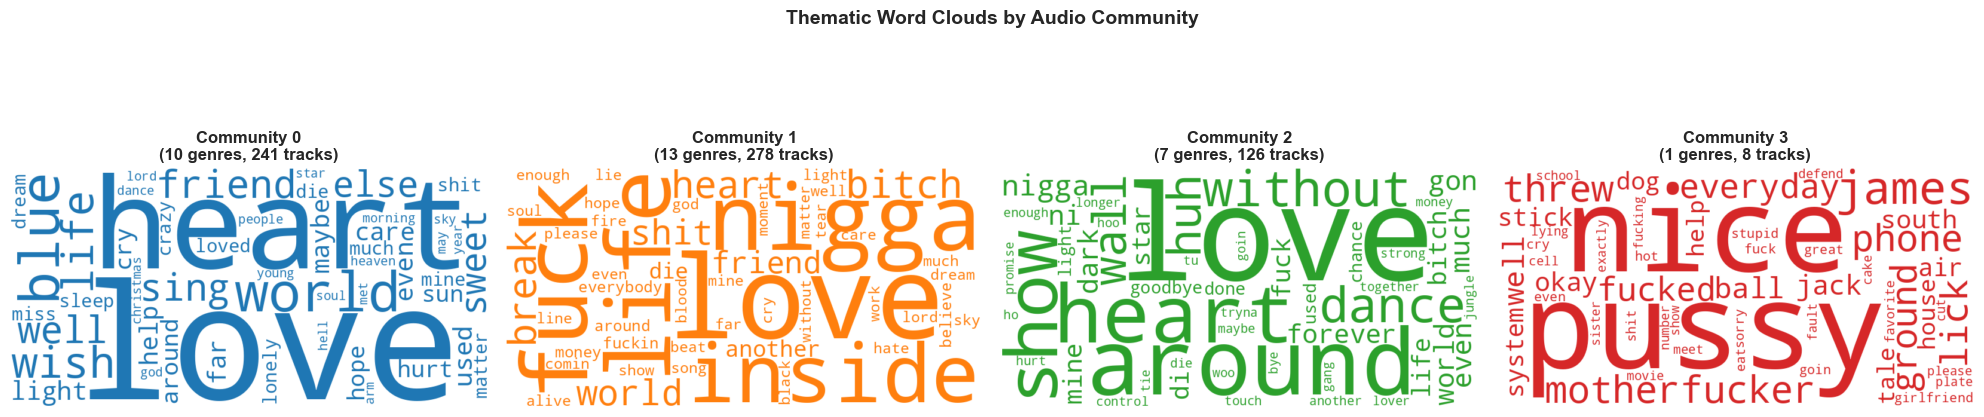

Saved to data/text_analysis_output/wordclouds_community.png


In [77]:
# Generate community word clouds
fig, axes = plt.subplots(1, n_comms_wc, figsize=(5 * n_comms_wc, 5))
if n_comms_wc == 1:
    axes = [axes]

for i, cid in enumerate(communities_in_data):
    comm_vector = get_community_tfidf_aggregated(df_lyrics, tfidf_matrix, cid)
    
    if comm_vector is None:
        axes[i].text(0.5, 0.5, 'No data', ha='center', va='center')
        axes[i].set_title(f'Community {cid}')
        axes[i].axis('off')
        continue
    
    top_terms = get_top_terms_from_vector(comm_vector, feature_names, top_n=WORDCLOUD_MAX_WORDS)
    color = COMMUNITY_COLOR_HEX.get(cid, '#333333')
    wc = create_wordcloud(top_terms, color, max_words=WORDCLOUD_MAX_WORDS)
    
    axes[i].imshow(wc, interpolation='bilinear')
    n_tracks = (df_lyrics['community_id'] == cid).sum()
    n_genres = df_lyrics[df_lyrics['community_id'] == cid]['genre'].nunique()
    axes[i].set_title(f'Community {cid}\n({n_genres} genres, {n_tracks} tracks)', fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Thematic Word Clouds by Audio Community', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'wordclouds_community.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved to {OUTPUT_DIR / 'wordclouds_community.png'}")

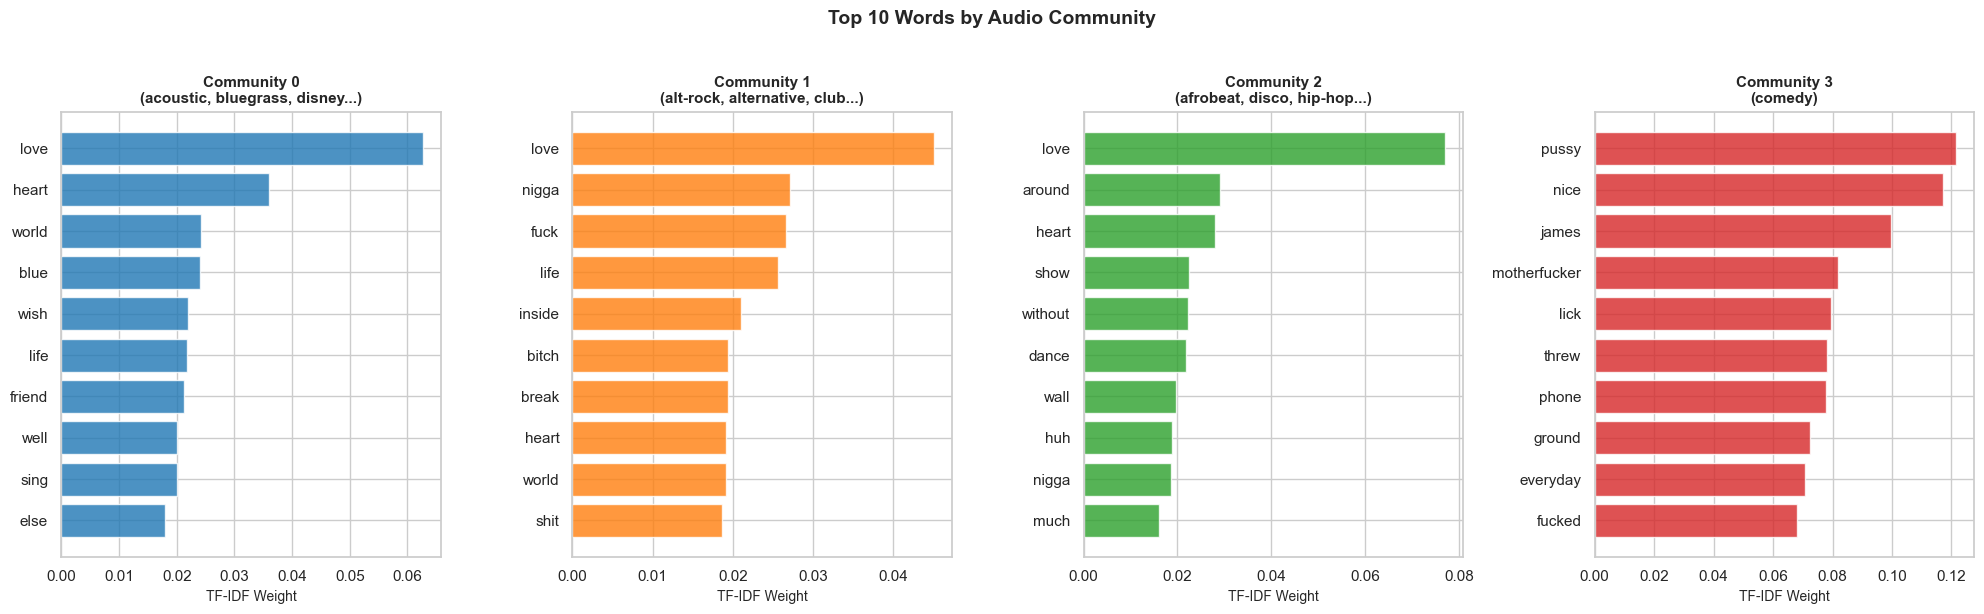

Saved to data/text_analysis_output/top_words_by_community.png


In [78]:
# Top words comparison bar chart
TOP_N_WORDS = 10

fig, axes = plt.subplots(1, n_comms_wc, figsize=(5 * n_comms_wc, 6), sharey=False)
if n_comms_wc == 1:
    axes = [axes]

for i, cid in enumerate(communities_in_data):
    ax = axes[i]
    comm_vector = get_community_tfidf_aggregated(df_lyrics, tfidf_matrix, cid)
    
    if comm_vector is None:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.set_title(f'Community {cid}')
        continue
    
    top_terms = get_top_terms_from_vector(comm_vector, feature_names, top_n=TOP_N_WORDS)
    words = list(top_terms.keys())[::-1]
    weights = list(top_terms.values())[::-1]
    
    color = COMMUNITY_COLOR_MAP[cid]
    ax.barh(words, weights, color=color, alpha=0.8)
    
    genres_in_comm = df_lyrics[df_lyrics['community_id'] == cid]['genre'].unique()
    genre_str = ', '.join(sorted(genres_in_comm)[:3]) + ('...' if len(genres_in_comm) > 3 else '')
    
    ax.set_xlabel('TF-IDF Weight', fontsize=10)
    ax.set_title(f'Community {cid}\n({genre_str})', fontsize=11, fontweight='bold')

plt.suptitle(f'Top {TOP_N_WORDS} Words by Audio Community', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top_words_by_community.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved to {OUTPUT_DIR / 'top_words_by_community.png'}")

### 5.1 Word Clouds by Archetypal Genre

We also generate word clouds for the same subset of archetypal genres used in the sentiment analysis, allowing direct comparison of vocabulary and emotional tone.

In [79]:
# Generate word clouds for archetypal genres
# Filter to genres that exist in our lyrics data
available_archetypal = [g for g in ARCHETYPAL_GENRES if g in set(genres_with_lyrics)]

# Organize by community for display
archetypal_by_community = {}
for genre in available_archetypal:
    cid = comm_map_audio.get(genre, 0)
    if cid not in archetypal_by_community:
        archetypal_by_community[cid] = []
    archetypal_by_community[cid].append(genre)

print(f"Archetypal genres for word clouds: {len(available_archetypal)}")
for cid in sorted(archetypal_by_community.keys()):
    genres = archetypal_by_community[cid]
    print(f"  Community {cid}: {genres}")

Archetypal genres for word clouds: 18
  Community 0: ['jazz', 'folk', 'acoustic', 'sad', 'singer-songwriter', 'bluegrass']
  Community 1: ['alternative', 'punk', 'emo', 'hardcore', 'electronic', 'industrial']
  Community 2: ['hip-hop', 'r-n-b', 'house', 'disco', 'synth-pop']
  Community 3: ['comedy']


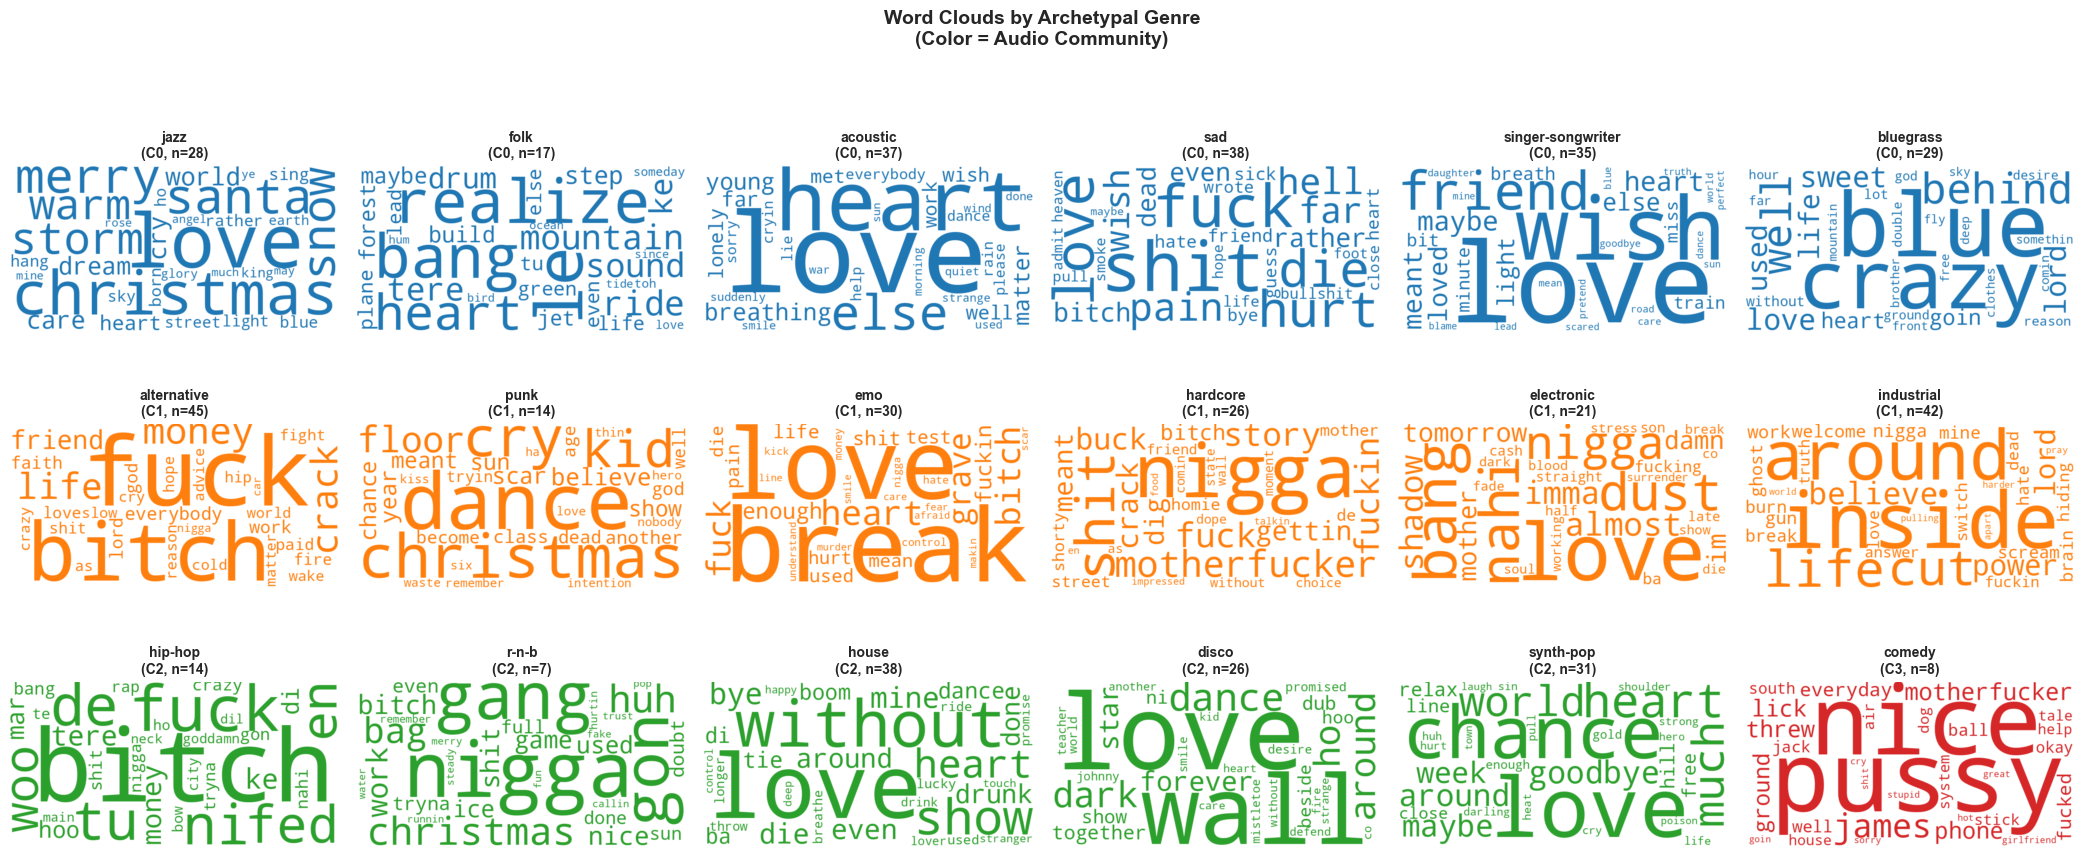

Saved to data/text_analysis_output/wordclouds_archetypal_genres.png


In [80]:
# Generate word clouds for archetypal genres (grid layout)
n_archetypal = len(available_archetypal)
n_cols = 6
n_rows = (n_archetypal + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5 * n_cols, 3 * n_rows))
axes = axes.flatten()

for i, genre in enumerate(available_archetypal):
    ax = axes[i]
    
    # Get genre TF-IDF vector
    genre_idx = list(genres_with_lyrics).index(genre)
    genre_vector = genre_tfidf[genre_idx]
    
    # Get top terms
    top_terms = get_top_terms_from_vector(genre_vector, feature_names, top_n=30)
    
    # Get community color
    cid = comm_map_audio.get(genre, 0)
    color = COMMUNITY_COLOR_HEX.get(cid, '#333333')
    
    # Create word cloud
    wc = create_wordcloud(top_terms, color, max_words=30)
    
    ax.imshow(wc, interpolation='bilinear')
    n_tracks = genre_track_counts.get(genre, 0)
    ax.set_title(f'{genre}\n(C{cid}, n={n_tracks})', fontsize=10, fontweight='bold')
    ax.axis('off')

# Hide unused subplots
for i in range(n_archetypal, len(axes)):
    axes[i].axis('off')

plt.suptitle('Word Clouds by Archetypal Genre\n(Color = Audio Community)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'wordclouds_archetypal_genres.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved to {OUTPUT_DIR / 'wordclouds_archetypal_genres.png'}")

## 6. Sentiment Analysis

We analyze the emotional tone of lyrics using VADER sentiment analysis.

**What to look for:**
- Do communities differ in overall sentiment (positive vs. negative)?
- Which genres are most positive/negative?
- Does sentiment align with genre stereotypes (e.g., is metal more negative)?

In [81]:
# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    """Get VADER compound sentiment score for text."""
    if pd.isna(text) or not text:
        return 0.0
    return sia.polarity_scores(text)['compound']

# Compute sentiment for all tracks
df_lyrics['sentiment'] = df_lyrics['lyrics'].apply(get_sentiment)

print(f"Sentiment computed for {len(df_lyrics)} tracks")
print(f"  Mean: {df_lyrics['sentiment'].mean():.3f}")
print(f"  Std: {df_lyrics['sentiment'].std():.3f}")
print(f"  Range: [{df_lyrics['sentiment'].min():.3f}, {df_lyrics['sentiment'].max():.3f}]")

Sentiment computed for 653 tracks
  Mean: 0.172
  Std: 0.871
  Range: [-1.000, 1.000]


### 6.1 Sentiment by Community

Box plots show the distribution of sentiment scores within each audio community.

/var/folders/vq/hbwc6_v92sg0d1qr62bc4_800000gn/T/ipykernel_89142/3781975516.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


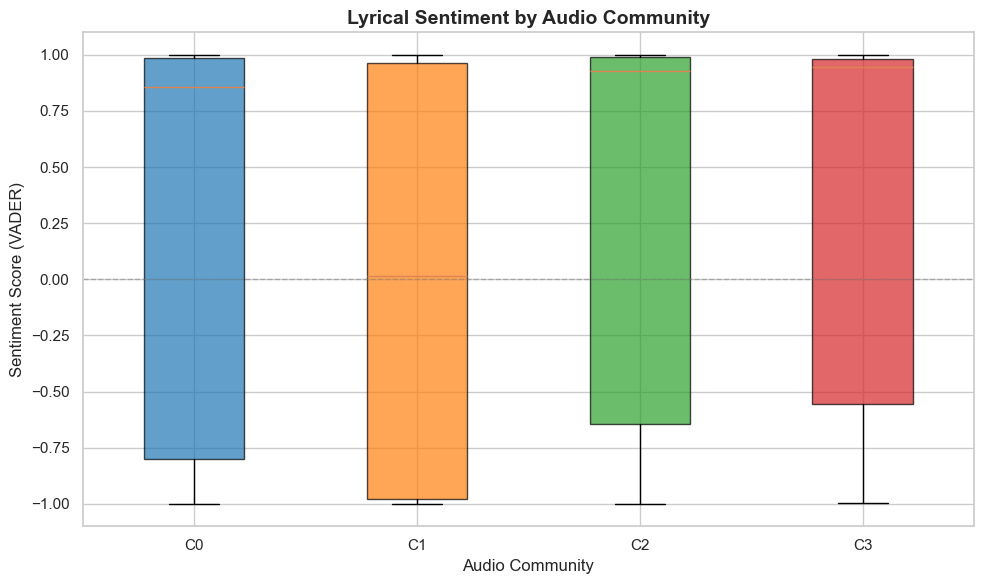

Saved to data/text_analysis_output/sentiment_by_community.png

Sentiment by community:
  Community 0: mean=0.289, std=0.835, n=241
  Community 1: mean=-0.019, std=0.888, n=278
  Community 2: mean=0.362, std=0.826, n=126
  Community 3: mean=0.311, std=0.927, n=8


In [82]:
# Sentiment by community box plot
fig, ax = plt.subplots(figsize=(10, 6))

communities_sorted = sorted(df_lyrics['community_id'].unique())

bp = ax.boxplot(
    [df_lyrics[df_lyrics['community_id'] == cid]['sentiment'].values for cid in communities_sorted],
    labels=[f'C{cid}' for cid in communities_sorted],
    patch_artist=True
)

for i, cid in enumerate(communities_sorted):
    bp['boxes'][i].set_facecolor(COMMUNITY_COLOR_MAP[cid])
    bp['boxes'][i].set_alpha(0.7)

ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Audio Community', fontsize=12)
ax.set_ylabel('Sentiment Score (VADER)', fontsize=12)
ax.set_title('Lyrical Sentiment by Audio Community', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sentiment_by_community.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved to {OUTPUT_DIR / 'sentiment_by_community.png'}")

# Summary
print("\nSentiment by community:")
for cid in communities_sorted:
    comm_sent = df_lyrics[df_lyrics['community_id'] == cid]['sentiment']
    print(f"  Community {cid}: mean={comm_sent.mean():.3f}, std={comm_sent.std():.3f}, n={len(comm_sent)}")

### 6.2 Sentiment by Genre (All Genres)

Bar chart showing mean sentiment for **all genres** with lyrics data, sorted from most negative to most positive.

In [83]:
# Compute mean sentiment per genre (ALL genres)
genre_sentiments = []

for genre in genres_with_lyrics:
    genre_df = df_lyrics[df_lyrics['genre'] == genre]
    if len(genre_df) > 0:
        genre_sentiments.append({
            'genre': genre,
            'sentiment_mean': genre_df['sentiment'].mean(),
            'sentiment_std': genre_df['sentiment'].std(),
            'n_tracks': len(genre_df),
            'community_id': comm_map_audio.get(genre, 0)
        })

df_genre_sentiment = pd.DataFrame(genre_sentiments)
df_genre_sentiment = df_genre_sentiment.sort_values('sentiment_mean', ascending=False)

print(f"Sentiment computed for {len(df_genre_sentiment)} genres")

Sentiment computed for 31 genres


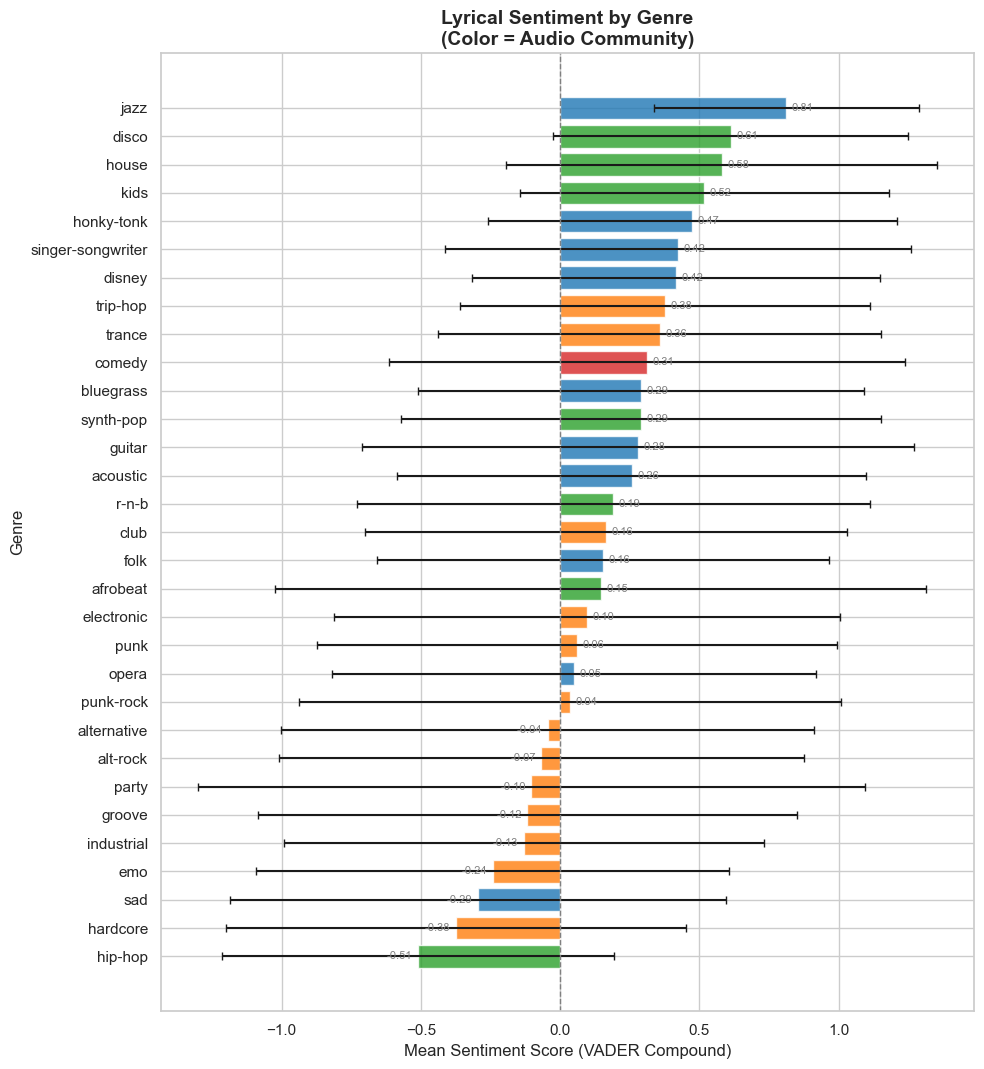

Saved to data/text_analysis_output/sentiment_by_genre.png


In [84]:
# Plot sentiment for ALL genres (sorted descending - highest at top)
# Sort ascending=True so highest values appear at top of horizontal bar chart
df_genre_sentiment_plot = df_genre_sentiment.sort_values('sentiment_mean', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(8, len(df_genre_sentiment_plot) * 0.35)))

bar_colors = [COMMUNITY_COLOR_MAP[cid] for cid in df_genre_sentiment_plot['community_id']]

bars = ax.barh(
    df_genre_sentiment_plot['genre'],
    df_genre_sentiment_plot['sentiment_mean'],
    xerr=df_genre_sentiment_plot['sentiment_std'],
    color=bar_colors, alpha=0.8, capsize=3
)

# Add value labels
for i, (idx, row) in enumerate(df_genre_sentiment_plot.iterrows()):
    x_pos = row['sentiment_mean'] + 0.02 if row['sentiment_mean'] >= 0 else row['sentiment_mean'] - 0.02
    ha = 'left' if row['sentiment_mean'] >= 0 else 'right'
    ax.text(x_pos, i, f"{row['sentiment_mean']:.2f}", va='center', ha=ha, fontsize=8, color='gray')

ax.axvline(x=0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Mean Sentiment Score (VADER Compound)', fontsize=12)
ax.set_ylabel('Genre', fontsize=12)
ax.set_title('Lyrical Sentiment by Genre\n(Color = Audio Community)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sentiment_by_genre.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved to {OUTPUT_DIR / 'sentiment_by_genre.png'}")

### 6.3 Sentiment by Archetypal Genres (Subset)

Bar chart showing mean sentiment for a **curated subset of well-known genres** from each audio community.

In [85]:
# Check which archetypal genres have lyrics data
available_archetypal = [g for g in ARCHETYPAL_GENRES if g in set(genres_with_lyrics)]
missing_archetypal = [g for g in ARCHETYPAL_GENRES if g not in set(genres_with_lyrics)]

print(f"Archetypal genres with lyrics data: {len(available_archetypal)}/{len(ARCHETYPAL_GENRES)}")
if missing_archetypal:
    print(f"Missing: {missing_archetypal}")

print(f"\nAvailable archetypal genres and their communities:")
for genre in available_archetypal:
    count = genre_track_counts.get(genre, 0)
    comm_id = comm_map_audio.get(genre, '?')
    print(f"  {genre}: {count} tracks (Community {comm_id})")

Archetypal genres with lyrics data: 18/18

Available archetypal genres and their communities:
  jazz: 28 tracks (Community 0)
  folk: 17 tracks (Community 0)
  acoustic: 37 tracks (Community 0)
  sad: 38 tracks (Community 0)
  singer-songwriter: 35 tracks (Community 0)
  bluegrass: 29 tracks (Community 0)
  alternative: 45 tracks (Community 1)
  punk: 14 tracks (Community 1)
  emo: 30 tracks (Community 1)
  hardcore: 26 tracks (Community 1)
  electronic: 21 tracks (Community 1)
  industrial: 42 tracks (Community 1)
  hip-hop: 14 tracks (Community 2)
  r-n-b: 7 tracks (Community 2)
  house: 38 tracks (Community 2)
  disco: 26 tracks (Community 2)
  synth-pop: 31 tracks (Community 2)
  comedy: 8 tracks (Community 3)


In [86]:
# Filter sentiment data to archetypal genres only
df_archetypal_sentiment = df_genre_sentiment[df_genre_sentiment['genre'].isin(available_archetypal)].copy()
df_archetypal_sentiment = df_archetypal_sentiment.sort_values('sentiment_mean', ascending=False)

print(f"Archetypal genres for subset plot: {len(df_archetypal_sentiment)}")

Archetypal genres for subset plot: 18


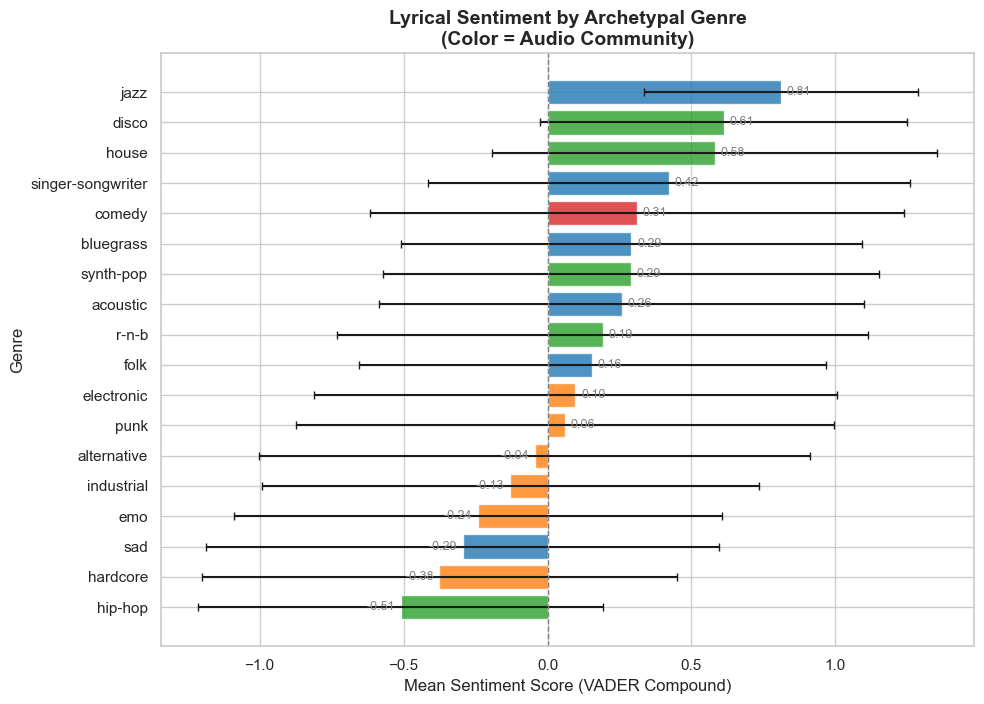

Saved to data/text_analysis_output/sentiment_by_genre_subset.png


In [87]:
# Plot sentiment for ARCHETYPAL genres (subset, sorted descending - highest at top)
# Sort ascending=True so highest values appear at top of horizontal bar chart
df_archetypal_sentiment_plot = df_archetypal_sentiment.sort_values('sentiment_mean', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(df_archetypal_sentiment_plot) * 0.4)))

bar_colors = [COMMUNITY_COLOR_MAP[cid] for cid in df_archetypal_sentiment_plot['community_id']]

bars = ax.barh(
    df_archetypal_sentiment_plot['genre'],
    df_archetypal_sentiment_plot['sentiment_mean'],
    xerr=df_archetypal_sentiment_plot['sentiment_std'],
    color=bar_colors, alpha=0.8, capsize=3
)

# Add value labels
for i, (idx, row) in enumerate(df_archetypal_sentiment_plot.iterrows()):
    x_pos = row['sentiment_mean'] + 0.02 if row['sentiment_mean'] >= 0 else row['sentiment_mean'] - 0.02
    ha = 'left' if row['sentiment_mean'] >= 0 else 'right'
    ax.text(x_pos, i, f"{row['sentiment_mean']:.2f}", va='center', ha=ha, fontsize=9, color='gray')

ax.axvline(x=0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Mean Sentiment Score (VADER Compound)', fontsize=12)
ax.set_ylabel('Genre', fontsize=12)
ax.set_title('Lyrical Sentiment by Archetypal Genre\n(Color = Audio Community)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sentiment_by_genre_subset.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved to {OUTPUT_DIR / 'sentiment_by_genre_subset.png'}")

## 7. Export Results

In [88]:
# Save lyrics with sentiment
df_lyrics.to_csv(OUTPUT_DIR / 'all_lyrics_with_sentiment.csv', index=False)
print(f"Saved to {OUTPUT_DIR / 'all_lyrics_with_sentiment.csv'}")

# Genre sentiment summary
genre_sent_summary = df_lyrics.groupby('genre').agg({
    'sentiment': ['mean', 'std', 'count'],
    'community_id': 'first'
}).round(3)
genre_sent_summary.columns = ['sentiment_mean', 'sentiment_std', 'n_tracks', 'community_id']
genre_sent_summary = genre_sent_summary.sort_values('sentiment_mean', ascending=False)
genre_sent_summary.to_csv(OUTPUT_DIR / 'genre_sentiment_summary.csv')
print(f"Saved to {OUTPUT_DIR / 'genre_sentiment_summary.csv'}")

Saved to data/text_analysis_output/all_lyrics_with_sentiment.csv
Saved to data/text_analysis_output/genre_sentiment_summary.csv


In [89]:
# Save top terms per genre
top_terms_df = []
for i, genre in enumerate(genres_with_lyrics):
    top_terms = get_top_terms_for_genre(i, top_n=15)
    comm_id = comm_map_audio.get(genre, -1)
    for term, weight in top_terms:
        top_terms_df.append({
            'genre': genre,
            'community_id': comm_id,
            'term': term,
            'tfidf_weight': weight
        })

pd.DataFrame(top_terms_df).to_csv(OUTPUT_DIR / 'genre_top_tfidf_terms.csv', index=False)
print(f"Saved to {OUTPUT_DIR / 'genre_top_tfidf_terms.csv'}")

Saved to data/text_analysis_output/genre_top_tfidf_terms.csv


## 8. Summary

In [90]:
print("="*60)
print("TEXT ANALYSIS SUMMARY")
print("="*60)
print()

print("Data:")
print(f"  Audio communities: {n_communities} (from GEXF)")
print(f"  Genres with lyrics: {len(genres_with_lyrics)}")
print(f"  Tracks with lyrics: {len(df_lyrics)}")
print(f"  TF-IDF vocabulary: {len(feature_names)} words")
print()

print("Sentiment:")
print(f"  Mean: {df_lyrics['sentiment'].mean():.3f}")
print(f"  Range: [{df_lyrics['sentiment'].min():.3f}, {df_lyrics['sentiment'].max():.3f}]")
print()

print("Outputs:")
outputs = [
    'wordclouds_community.png',
    'wordclouds_archetypal_genres.png',
    'top_words_by_community.png',
    'sentiment_by_community.png',
    'sentiment_by_genre.png',
    'sentiment_by_genre_subset.png',
    'all_lyrics_with_sentiment.csv',
    'genre_sentiment_summary.csv',
    'genre_top_tfidf_terms.csv',
]
for output in outputs:
    print(f"  {OUTPUT_DIR / output}")

print()
print("="*60)

TEXT ANALYSIS SUMMARY

Data:
  Audio communities: 4 (from GEXF)
  Genres with lyrics: 31
  Tracks with lyrics: 653
  TF-IDF vocabulary: 1237 words

Sentiment:
  Mean: 0.172
  Range: [-1.000, 1.000]

Outputs:
  data/text_analysis_output/wordclouds_community.png
  data/text_analysis_output/wordclouds_archetypal_genres.png
  data/text_analysis_output/top_words_by_community.png
  data/text_analysis_output/sentiment_by_community.png
  data/text_analysis_output/sentiment_by_genre.png
  data/text_analysis_output/sentiment_by_genre_subset.png
  data/text_analysis_output/all_lyrics_with_sentiment.csv
  data/text_analysis_output/genre_sentiment_summary.csv
  data/text_analysis_output/genre_top_tfidf_terms.csv

